# Obtaining the stationary distribution

## Start by solving the model and obtaining the policy functions

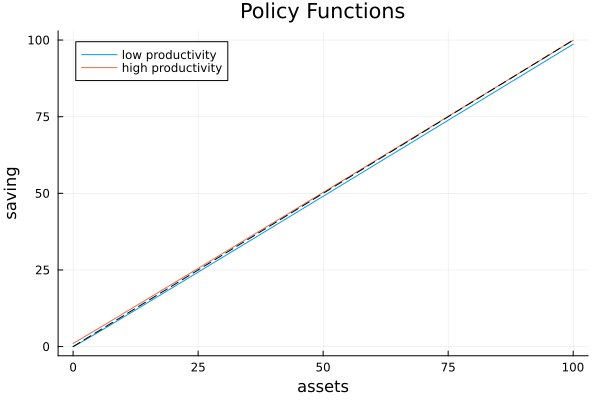

In [1]:
using Plots, Setfield, Interpolations, Random, Parameters

include("Functions/VFI_update_spline.jl")

## 1. Define parameters
@with_kw struct NumericalParameters
    nk = 100 # Number of points on the asset grid
    nz = 2 # Number of points on the log-productivity grid
    crit = 1.0e-5 # Numerical precision
    maxk = 100 # Maximum assets
    mink = 0.0 # Minimum assets (no borrowing case)
    T = 50000 # Used later for simulation
    DEGM_normalization = false # normalize CDF in transition step for DEGM
end

n_par = NumericalParameters()

@with_kw struct EconomicParameters
    r = 0.04 # Real Rate
    ξ = 2.0 # Coefficient of relative risk aversion
    β = 0.95 # Discount factor
    ρ  = 0.98  # AR(1) persistence
    b = n_par.mink # borrowing limit
end

m_par = EconomicParameters()

## 2. Grids and transitions
include("Functions/Tauchen.jl")
grid_z, Π, bounds = Tauchen(m_par.ρ, n_par.nz)
grid_z = exp.(grid_z)  # transform to levels

struct Grids
    k # capital
    z # income
end

gri   = Grids(
            exp.(collect(range(log(1),log(n_par.maxk-n_par.mink+1);length = n_par.nk))) .- 1 .+ n_par.mink,
            grid_z
        )

## 3. Generate meshes
# Meshes of capital and productivity
meshes = (
            k = [k for k in gri.k, z in gri.z],
            z = [z for k in gri.k, z in gri.z]
         )

## 4. Define the utility function
if m_par.ξ == 1.0
    util(c)     = log.(c) # Utility
    mutil(c)    = 1.0 ./c  # Marginal utility
    invmutil(mu) = 1.0 ./mu # inverse marginal utility
else
    util(c)      = 1.0/(1.0 - m_par.ξ) .* c .^(1-m_par.ξ) # Utility
    mutil(c)     = 1.0 ./(c .^m_par.ξ) # Marginal utility
    invmutil(mu) = 1.0/(mu .^(1.0 ./m_par.ξ)) # inverse marginal utility
end

## 5. Solve the Household Problem
Y = meshes.z + meshes.k*(1+m_par.r) # Cash at hand (Labor income plus assets cum dividend)
V    = zeros(n_par.nk,n_par.nz) # Initialize Value Function
kprime = zeros(n_par.nk,n_par.nz) # Initialize Policy Function
distVF = ones(1) # Initialize Distance
iterVF = 1 # Initialize Iteration count
while distVF[iterVF]>n_par.crit # Value Function iteration loop: until distance is smaller than crit.
# Update Value Function using off-grid search
    Vnew,kprime = VFI_update_spline(V,Y,util,m_par,n_par,gri,Π) # Optimize given cont' value
    dd          = maximum(abs.(Vnew-V)) # Calculate distance between old guess and update
    V          = Vnew # Update Value Function
    iterVF     += 1 # Count iterations
    append!(distVF,dd)   # Save distance
end
V      = reshape(V,n_par.nk,n_par.nz)

## Plot Policy Functions
figure1 = plot(gri.k,kprime,labels=["low productivity" "high productivity"],legend = :topleft) # Plot policy functions
plot!(gri.k,gri.k,linestyle = :dash,linecolor= :black,labels = nothing) # Add 45° line
title!("Policy Functions")
xlabel!("assets")
ylabel!("saving")

## 1. Simulation of a panel of heterogeneous individuals/households

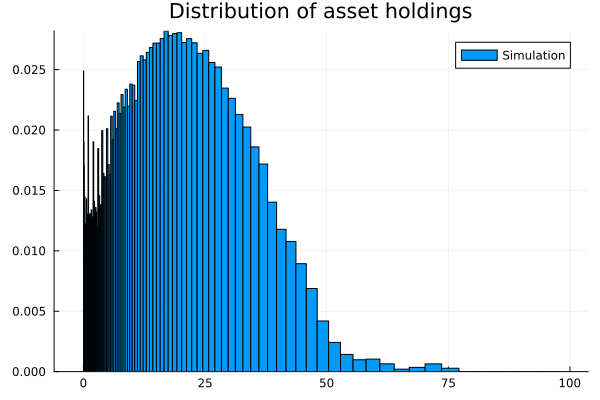

In [2]:
## Obtain the Stationary Distribution by simulating the economy
# Define an off-grid savings function by interpolation
timer = time()
Saving = interpolate((gri.k,gri.z),kprime,Gridded(Linear())) # Continuous Savings Function as Linear Interpolant
# Simulate the exogeneous state
Random.seed!(42)
PI      = cumsum(Π,dims = 2)         # Cummulative Transition matrix
ϵ       = rand(n_par.T)           # Random numbers for simulation
S       = rand(1:n_par.nz,n_par.T)  # Starting value
k       = zeros(n_par.T)          # Starting value for NEXT PERIODS ASSETS assets
for t=2:n_par.T
    S[t]    = count(PI[S[t-1],:].< ϵ[t])+1   # Update productivity state
    k[t]    = Saving(k[t-1],gri.z[S[t]])     # Update Assest Holdings
end
timeSim   = time() - timer

# Plot histogram3
figure2 = histogram(k[1:end],bins=(gri.k[1:end-1] + gri.k[2:end])/2, normalize=:pdf,label="Simulation")
title!("Distribution of asset holdings")
display(figure2)

## 2. Histogram/"Lottery" method

This method, developed in Young (2010), has the advantage of avoiding the need to simulate a full panel of agents.

### How does it work?
Remember, we discretized the economy so that asset holdings lie on a grid:
$$[a_1, a_2,..., a_N]$$

Suppose there is a continuum of agents, of total measure $m$, whose desired saving lies somewhere between two neighboring grid points $a_n$ and $a_{n+1}$. Call the “true” desired asset level $a$, with $a_n \leq a \leq a_{n+1}$. Instead of forcing everyone onto the same grid point, we split the mass $m$ between $a_n$ and $a_{n+1}$ in proportion to how close $a$ is to each point. Concretely:

1.	Define
$$p \;=\; \frac{a - a_n}{\,a_{n+1} - a_n\,}$$

- If $a$ is very close to $a_n$, then $p$ is close to 0.
- If $a$ is very close to $a_{n+1}$, then $p$ is close to 1.

2.	Assign a mass of
$m \times (1 - p)$
to the grid point $a_n$, and a mass of
$m \times p$
to the grid point $a_{n+1}$.

Thus, if $a = a_n$, then $p = 0$ and 100% of the mass $m$ is placed on $a_n$. If $a = a_{n+1}$, then $p = 1$ and all of $m$ is placed on $a_{n+1}$. For intermediate values of $a$, the mass splits linearly between the two adjacent points according to $p$.

Finally, recall that the “true” asset level $a$ is determined by the policy function $a^*(a,y)$. Whenever an agent’s continuous choice $a$ satisfies $a_n \le a^*(a,y) \le a_{n+1}$, we apply the procedure above to distribute that agent’s mass across the two nearest grid points.
<!-- 
Imagine that there is a measure $m$ of people that choose to save $a$, where $a \in [a_n, a_{n+1}]$, then, the mass assigned to the grid point $a_n$ (i.e. the amount of people at this grid point) is equal to $m \times (1-p)$ and the mass assigned to the grid point $a_{n+1}$ is $m \times p$, where $p$ is a weight that is calculated as:

$$
p = \frac{a - a_n}{a_{n+1} - a_{n}}
$$

So, if $a$ is very close to $a_n$, then most of the mass (i.e. most of the people) $m$ will be assigned to this point. In the limit case, 100% of the people will be assigned to $a_n$. The converse is true for $a_{n+1}$.

$a \rightarrow$ Is then given by the policy function (i.e. $a^*(a,y)$) -->

### Let us first start considering a simple case where $a^*(a,y)$ has only one mass point

In other words $a^* = $ some value, and thus it does not depend on previous assets nor income.

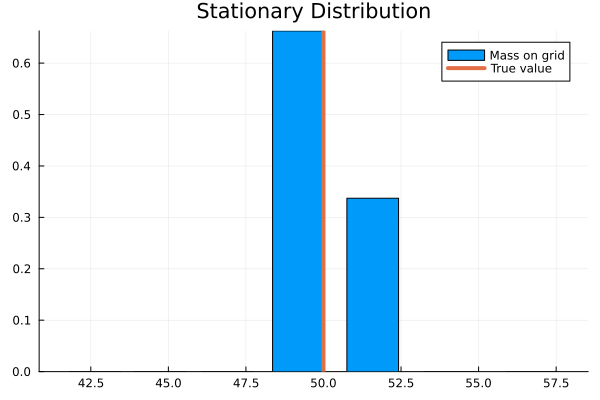

In [3]:
# NOTE: In the VFI code we called a^*(a,y) as kprime, so I will continue using kprime to refer to the policy function. But if it is confusing, feel free to rename it to a_star or similar.

kprime1 = 50 # True value
mass = 1.0   # Mass at the true value

idk = searchsortedlast(gri.k,kprime1) # find the next lowest point on grid for policy

# Calculate linear interpolation weights
distance                 = kprime1 - gri.k[idk]
weightright              = distance ./ (gri.k[idk.+1]-gri.k[idk])
weightleft               = 1 .- weightright

p = zeros(n_par.nk)
p[idk] = weightleft
p[idk+1] = weightright

p0 = bar(gri.k[idk-3:idk+3], p[idk-3:idk+3], title="Stationary Distribution", label = "Mass on grid")
plot!(p0, [kprime1], seriestype = :vline, label="True value", linewidth = 4)

### Let us generalize to the case that $a^*(a,y)$ contains more than just one point for assets but only one income state

Now, the function $a^*(a)$ is a vector that depends only on the previous asset level $a$ but does not depend on income. This means that in this case, we seek to obtain transition matrix whose entries give the probability of moving from one asset level to another.

$$
P \;=\;
\begin{array}{cc}
         & a_{1} \qquad a_{2} \qquad a_{3} \qquad \cdots \quad a_{N} \\[6pt]
\begin{matrix}
a_{1} \\[4pt]
a_{2} \\[4pt]
a_{3} \\[4pt]
\vdots \\[4pt]
a_{N}
\end{matrix}
&
\begin{bmatrix}
\gamma_{1\to 1} & \gamma_{1\to 2} & \gamma_{1\to 3} & \cdots & \gamma_{1\to N} \\[6pt]
\gamma_{2\to 1} & \gamma_{2\to 2} & \gamma_{2\to 3} & \cdots & \gamma_{2\to N} \\[6pt]
\gamma_{3\to 1} & \gamma_{3\to 2} & \gamma_{3\to 3} & \cdots & \gamma_{3\to N} \\[6pt]
\vdots          & \vdots          & \vdots          & \ddots & \vdots          \\[6pt]
\gamma_{N\to 1} & \gamma_{N\to 2} & \gamma_{N\to 3} & \cdots & \gamma_{N\to N} \\
\end{bmatrix}
\end{array}
$$

with $\gamma_{i \rightarrow j}$ being the each of the weight obtained using the formula for $p$.

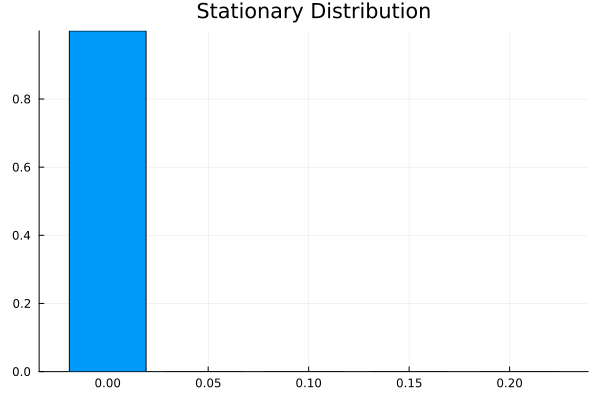

In [4]:
kprime_lowy = kprime[:,1]
idk = [searchsortedlast(gri.k,k) for k in kprime_lowy[:]] # find the next lowest point on grid for policy
idk = reshape(idk,size(kprime_lowy))
idk[kprime_lowy .<= gri.k[1]]    .= 1           # remain in the index set
idk[kprime_lowy .>= gri.k[end]]  .= n_par.nk-1   # remain in the index set

# Calculate linear interpolation weights
distance                 = kprime_lowy - gri.k[idk]
weightright              = distance ./ (gri.k[idk.+1]-gri.k[idk])
weightleft               = 1 .- weightright

Γ = zeros(eltype(kprime_lowy),n_par.nk,n_par.nk) # Assets now x Assets next

# Fill this array with probabilities
for kk=1:n_par.nk # all current asset states
    Γ[kk,idk[kk]]   =  weightleft[kk] # probability to move left  to optimal policy choice
    Γ[kk,idk[kk]+1] =  weightright[kk] # probability to move right to optimal policy choice
end

eigdecomp = eigen(Γ')
x  = real(eigdecomp.vectors[:,findall(isapprox.(eigdecomp.values,1.0,atol=1.0e-6))])   # Solve x* = x* Γ
StDist = x./sum(x)        # Normalize Eigenvector to sum(x)=1

plt_dist_lowy = bar(gri.k[1:5],StDist[1:5], title = "Stationary Distribution", label="") # Given that almost all the mass is on the first grid point, only plot the first 5 points

### Finally, consider the case that $a^*(a,y)$ contains more than one point for assets and more than one income state

In this case, since the optimal asset choice $a^*(a,y)$ depends on the current income state y, and since income evolves according to a Markov chain $\Pi$, we must adjust (i.e., “weight”) each asset‐transition probability by the probability of moving from one income state to another. In other words, whenever we consider how likely it is for an agent to go from assets $a_n$ to $a_{n+1}$, we also multiply by the chance that their income switches from state y to the next income state.

$p_{1 \rightarrow 1} \cdot \pi_{1 \rightarrow 1} \qquad p_{2 \rightarrow 1} \cdot \pi_{1 \rightarrow 1} \qquad \cdots \forall \ \text{income states}\\$
$p_{1 \rightarrow 1} \cdot \pi_{1 \rightarrow 2} \qquad p_{2 \rightarrow 2} \cdot \pi_{1 \rightarrow 2} \qquad \cdots \forall \ \text{income states}\\$
$p_{1 \rightarrow 1} \cdot \pi_{1 \rightarrow 3} \qquad p_{2 \rightarrow 3} \cdot \pi_{1 \rightarrow 3} \qquad \cdots \forall \ \text{income states}\\$
$\qquad \text{etc.} \qquad \qquad \ \text{etc.} \\$

$$
\gamma_{(i,j)\,\to\,(i',\,j')}
\;=\;
\begin{cases}
\displaystyle
\pi_{jj'} \cdot \bigl[\,1 - p\bigl(a_i,\,y_j\bigr)\bigr],
&\text{if }i' = n(i,j),\\[1em]
\displaystyle
\pi_{jj'} \cdot p\bigl(a_i,\,y_j\bigr),
&\text{if }i' = n(i,j) + 1,\\[1em]
0,
&\text{otherwise.}
\end{cases}
$$


$$
\Gamma = \left[ \gamma_{(i,j) \rightarrow (i',j')} \right]_{(i,j)}^{(i',j')}
$$

where $\Gamma$ tells us the transition probability among the combination of all possible states of the economy.

Now, we can solve for the distribution $\Phi$, which evolves as:

$$
\Phi_{t+1} = \Phi_t \cdot \Gamma
$$

1. ... by iteration. $\Phi_{t+2} = \Phi_{t+1} \cdot \Gamma$ and so on until convergence (i.e until the difference between $\Phi_{t+n+1}$ and $\Phi_{t+n}$ is zero)

2. ... or by direct calculation. The stationary distribution implies that $\Phi = \Phi \cdot \Gamma \rightarrow (1 - \Gamma) \Phi = 0$. This is similar to the "characteristic equation" that you have seen in Linear Algebra courses. Which means that the distribution is given by the eigenvector that solves this equation.


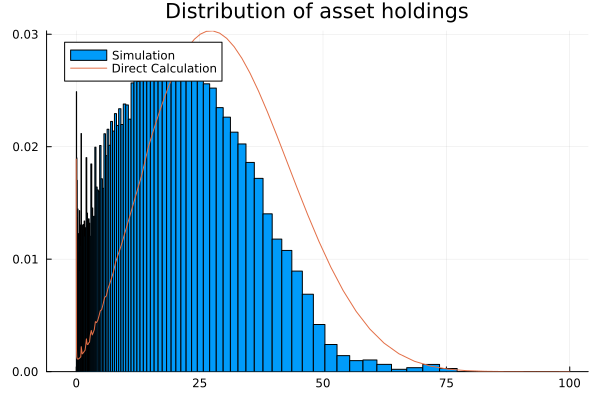

In [5]:
timer = time() # time Young method 
idk                  = [searchsortedlast(gri.k,k) for k in kprime[:]] # find the next lowest point on grid for policy
idk = reshape(idk,size(kprime))
idk[kprime .<= gri.k[1]]    .= 1           # remain in the index set
idk[kprime .>= gri.k[end]]  .= n_par.nk-1   # remain in the index set

# Calculate linear interpolation weights
distance                 = kprime - gri.k[idk]
weightright              = distance ./ (gri.k[idk.+1]-gri.k[idk])
weightleft               = 1 .- weightright

Trans_array = zeros(eltype(kprime),n_par.nk,n_par.nz,n_par.nk,n_par.nz) # Assets now x Income now x Assets next x Income next
# Fill this array with probabilities
for zz=1:n_par.nz # all current income states
    for kk=1:n_par.nk # all current asset states
        Trans_array[kk,zz,idk[kk,zz],:]   =  weightleft[kk,zz] *reshape(Π[zz,:],1,1,1,n_par.nz) # probability to move left  to optimal policy choice
        Trans_array[kk,zz,idk[kk,zz]+1,:] =  weightright[kk,zz] *reshape(Π[zz,:],1,1,1,n_par.nz) # probability to move right to optimal policy choice
    end
end
Γ  = reshape(Trans_array,n_par.nk*n_par.nz, n_par.nk*n_par.nz) # Turn 4-d array into a transition matrix stacking 2 dimensions
eigdecomp = eigen(Γ')
x  = real(eigdecomp.vectors[:,findall(isapprox.(eigdecomp.values,1.0,atol=1.0e-6))])   # Solve Φ = Φ Γ
StDist = x./sum(x)        # Normalize Eigenvector to sum(x)=1

timeYoung = time() - timer

# Obtain the marginal distribution
marginal_k      = sum(reshape(StDist,n_par.nk, n_par.nz),dims=2)
marginal_y      = sum(reshape(StDist,n_par.nk, n_par.nz),dims=1)
K               = dot(marginal_k,gri.k)

## 7. Compare solutions
figure2 = histogram(k[1:end],bins=(gri.k[1:end-1] + gri.k[2:end])/2, normalize=:pdf,label="Simulation")
plot!(gri.k,marginal_k,label="Direct Calculation",legend= :topleft)
title!("Distribution of asset holdings")
display(figure2)

## Comparison across methods

In [6]:
println("")
println("Average Asset holdings")
println("----------------------")
println("Simulation: ",sum(k)/length(k))
println("Young     : ",K)
println("----------------------")
println("Time for calculation")
println("--------------------")
println("Simulation: ",timeSim)
println("Young     : ",timeYoung)


Average Asset holdings
----------------------
Simulation: 22.662296623259763
Young     : 21.93039754407986
----------------------
Time for calculation
--------------------
Simulation: 0.23049592971801758
Young     : 0.8728740215301514


## Calculate distribution summary statistics

In [7]:

pdf_wealth = marginal_k
cdf_wealth = cumsum(pdf_wealth; dims = 1)

l = @layout [a ; b; c; d]
p1 = plot(gri.k,pdf_wealth,label="",title="Marginal PDF of Wealth")
p2 = plot(gri.k,cdf_wealth,label="",title="Marginal CDF of Wealth")
figure = plot(p1,p2,layout=(1,2))

include("Functions/LinInterpol.jl")

Top10Wealth = mylinearinterpolate(cdf_wealth[:], gri.k, [0.999999])[1] - mylinearinterpolate(cdf_wealth[:], gri.k, [0.9])[1]
Top10WealthShare = Top10Wealth / K
println("Top 10 Wealth - Share of Total Capital -")
println(Top10WealthShare)

function gini(x, pdf)
    s = 0.0
    gini = 0.0
    for i in eachindex(x)
        gini -= pdf[i] * s
        s += x[i] * pdf[i]
        gini -= pdf[i] * s
    end
    gini /= s
    gini += 1.0
    return gini
end

gini_coef = gini(gri.k,pdf_wealth)
println("Gini Coefficient")
println(gini_coef)

Average_welfare = dot(V, StDist)

pdf_income = marginal_y

V_wealth = V * pdf_income'
V_wealth = V_wealth .* pdf_wealth
V_wealth_cumsum = cumsum(V_wealth, dims=1)

V10lowpctl = mylinearinterpolate(cdf_wealth[:], V_wealth_cumsum[:], [0.1])[1]
V10highpctl = mylinearinterpolate(cdf_wealth[:], V_wealth_cumsum[:], [0.999999])[1] -  mylinearinterpolate(cdf_wealth[:], V_wealth_cumsum[:], [0.9])[1]



Top 10 Wealth - Share of Total Capital -
2.1290748567398032
Gini Coefficient
0.3541441639524


-0.6258079548445519